# 🏥 EDA — Dataset de Morbilidad del Hospital de Pitalito

Análisis exploratorio de `Morbilidad_urgencias_Hospital_Pitalito_20260406.xlsx`.  
Contiene registros reales de urgencias con variables demográficas, diagnóstico sindrómico y nivel de triaje.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.config import MORBILIDAD_XLSX, TRIAJE_EXCLUIDO, TRIAJE_LABELS

df = pd.read_excel(MORBILIDAD_XLSX)
print(f'Dimensiones: {df.shape}')
print(f'Columnas: {list(df.columns)}')
df.head()

Dimensiones: (59025, 21)
Columnas: ['Periodo', 'Ingreso', 'FechaIngreso', 'Triage', 'Unidad', 'FechaHistoria', 'EspecialidadMedico', 'Entidad', 'DxSindromatico', 'CodigoDiagnostico', 'NombreDiagnostico', 'Sexo', 'FechaNacimiento', 'GrupoEtario1', 'GrupoEtario2', 'TipoRegimen', 'Edad', 'UnidadEdad', 'MunicipioRes', 'BarrioVereda', 'Direccion']


,Periodo,Ingreso,FechaIngreso,Triage,Unidad,FechaHistoria,EspecialidadMedico,Entidad,DxSindromatico,CodigoDiagnostico,...,Sexo,FechaNacimiento,GrupoEtario1,GrupoEtario2,TipoRegimen,Edad,UnidadEdad,MunicipioRes,BarrioVereda,Direccion
0,2023-01-01,2795237,2023-01-31 23:23:22,3,URGENCIAS TRAUMA Y PROCEDIMIENTOS,2023-01-31 23:29:41,MEDICINA GENERAL,NUEVA EPS,CONTUSIONES,S019,...,Masculino,1998-01-31,Entre 15 y 44,Entre 25 y 29,Subsidiado,25,Años,41551,PANORAMA,CALLE 8 SUR N 1 6- 60
1,2023-01-01,2795236,2023-01-31 23:15:32,3,URGENCIAS CONSULTA Y PROCEDIMIENTOS,2023-01-31 23:22:39,MEDICINA GENERAL,ASMET SALUD CONTRIBUTIVO,DOLOR ABDOMINAL CONSTANTE,R104,...,Femenino,1986-10-05,Entre 15 y 44,Entre 35 y 39,Subsidiado,36,Años,41668,VEREDA,VEREDA LA PARDERA
2,2023-01-01,2795235,2023-01-31 23:12:51,3,URGENCIAS CONSULTA Y PROCEDIMIENTOS,2023-01-31 23:21:09,MEDICINA GENERAL,NUEVA EPS,DOLOR TORAXICO,R073,...,Masculino,1999-06-07,Entre 15 y 44,Entre 20 y 24,Contributivo,23,Años,41551,BARRIO GENERAL,CONJUNTO LA CASTELLANA- NO SABE NOMENCLATURA
3,2023-01-01,2795234,2023-01-31 23:08:26,3,URGENCIAS TRAUMA Y PROCEDIMIENTOS,2023-01-31 23:17:18,MEDICINA GENERAL,NUEVA EPS,LESIONES POR VIOLENCIA,R456,...,Femenino,2004-04-20,Entre 15 y 44,Entre 15 y 19,Subsidiado,18,Años,41551,HACIENDA DE LABOYOS - VDA -,VEREDA HACIENDA LABOYOS
4,2023-01-01,2795231,2023-01-31 22:51:07,3,URGENCIAS CONSULTA Y PROCEDIMIENTOS,2023-01-31 23:08:50,MEDICINA GENERAL,UNION TEMPORAL TOLIHUILA,DOLOR AGUDO,I872,...,Masculino,1947-07-03,Mayores de 60,Entre 75 y 79,Otro,75,Años,41551,CALAMO,CARRERA 14 A NO. 8 - 05


## 1. Limpieza básica y distribución de Triaje

In [ ]:
# Contar valores únicos por columna
valores_unicos = df.nunique()
# Mostrar resultado
print("Cantidad de valores únicos por columna:\n")
print(valores_unicos)


In [ ]:
# Contar valores faltantes por columna
faltantes = df.isnull().sum()
print(faltantes)

In [ ]:
#Filas duplicadas completas
duplicadas = df.duplicated().sum()
print("Filas completamente duplicadas:", duplicadas)

In [ ]:
# REVISIÓN DE ERRORES EVIDENTES / FUERA RANGO
# ==========================================

print("===== VALIDACIÓN DE DATOS =====\n")

# ------------------------------------------
# 1. Edad fuera de rango
# ------------------------------------------
print("1. EDAD FUERA DE RANGO")

edad_error = df[(df["Edad"] < 0) | (df["Edad"] > 120)]

print("Registros con edad inválida:", len(edad_error))


# ------------------------------------------
# 2. Triage fuera de rango esperado (1 a 5)
# ------------------------------------------
print("\n2. TRIAGE INVÁLIDO")

triage_error = df[~df["Triage"].isin([1,2,3,4,5])]

print("Registros con triage inválido:", len(triage_error))


# ------------------------------------------
# 3. Sexo inconsistente
# ------------------------------------------
print("\n3. SEXO INVÁLIDO")

sexo_validos = ["M", "F", "Masculino", "Femenino"]

sexo_error = df[~df["Sexo"].astype(str).str.strip().isin(sexo_validos)]

print("Registros con sexo inconsistente:", len(sexo_error))


# ------------------------------------------
# 4. Fechas inconsistentes
# ------------------------------------------
print("\n4. FECHAS INVÁLIDAS O FUTURAS")

fechas = ["FechaIngreso", "FechaHistoria", "FechaNacimiento"]

for col in fechas:
    
    df[col] = pd.to_datetime(df[col], errors="coerce")
    
    invalidas = df[col].isna().sum()
    futuras = (df[col] > pd.Timestamp.today()).sum()
    
    print(f"{col}:")
    print(f" - Fechas inválidas: {invalidas}")
    print(f" - Fechas futuras: {futuras}")


# ------------------------------------------
# 5. Fecha nacimiento posterior ingreso
# ------------------------------------------
print("\n5. NACIMIENTO POSTERIOR AL INGRESO")

error_fecha = df[df["FechaNacimiento"] > df["FechaIngreso"]]

print("Registros inconsistentes:", len(error_fecha))


# ------------------------------------------
# 6. Valores vacíos en campos críticos
# ------------------------------------------
print("\n6. CAMPOS CRÍTICOS VACÍOS")

criticos = ["Ingreso", "Triage", "Edad", "Sexo", "Entidad"]

for col in criticos:
    print(f"{col}: {df[col].isna().sum()} vacíos")

Registros originales: 59,025
Registros después de excluir triaje [0, 5]: 59,001


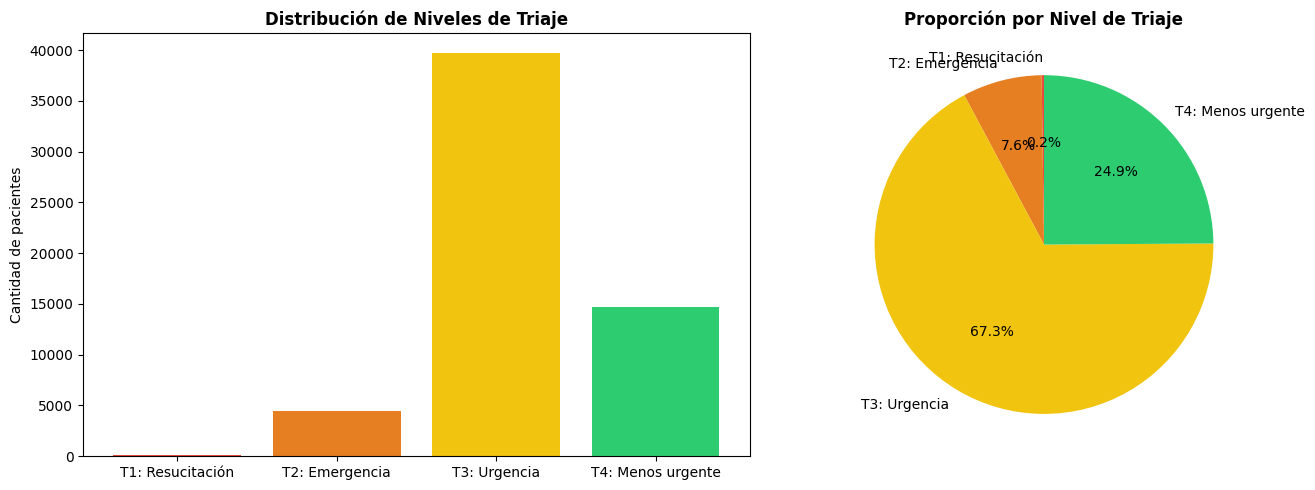

In [ ]:
# Excluir triajes con muy pocas muestras
df_clean = df[~df['Triage'].isin(TRIAJE_EXCLUIDO)].copy()
print(f'Registros originales: {len(df):,}')
print(f'Registros después de excluir triaje {TRIAJE_EXCLUIDO}: {len(df_clean):,}')

# Distribución de triaje
triage_cts = df_clean['Triage'].value_counts().sort_index()
labels = [f'T{k}: {TRIAJE_LABELS.get(k,"?")}'  for k in triage_cts.index]
colores = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(labels, triage_cts.values, color=colores[:len(triage_cts)])
axes[0].set_ylabel('Cantidad de pacientes')
axes[0].set_title('Distribución de Niveles de Triaje', fontweight='bold')

axes[1].pie(triage_cts.values, labels=labels, colors=colores[:len(triage_cts)],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción por Nivel de Triaje', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Top DxSindromatico

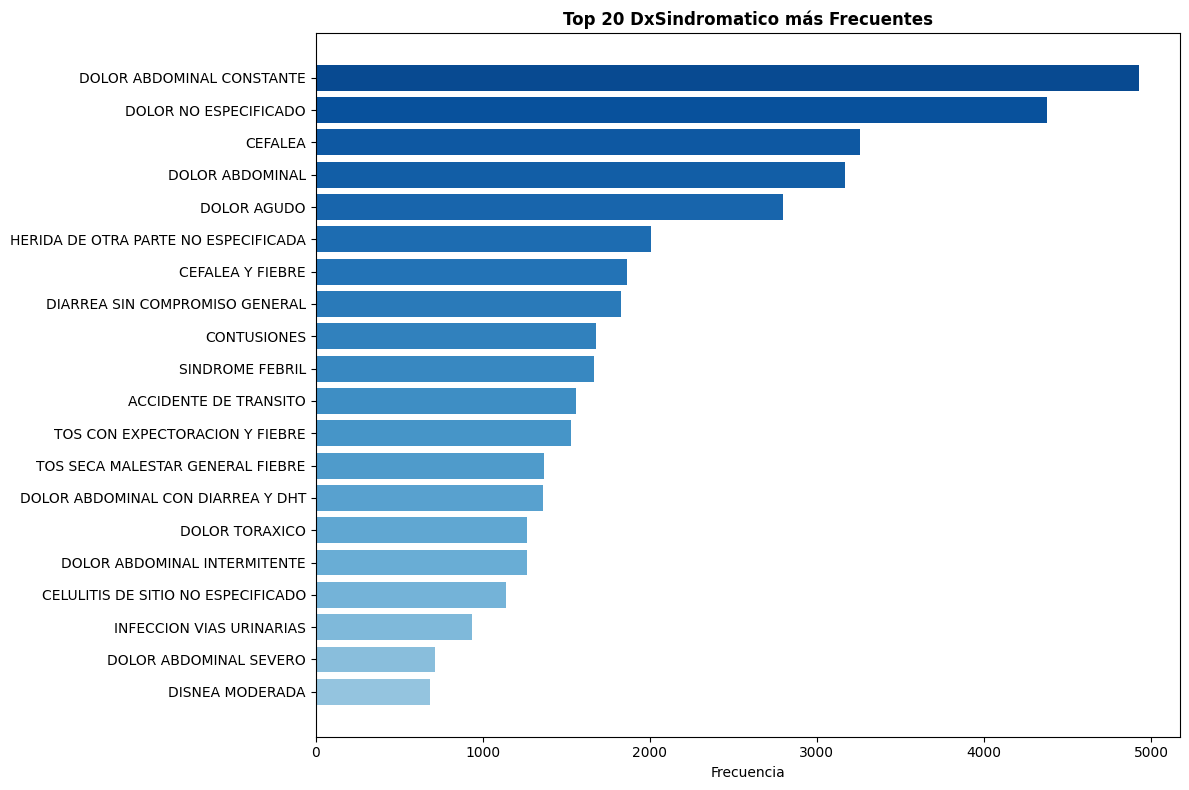


Total DxSindromatico únicos: 297


In [3]:
top_n = 20
top_dx = df_clean['DxSindromatico'].value_counts().head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top_dx.index[::-1], top_dx.values[::-1],
        color=plt.cm.Blues(np.linspace(0.4, 0.9, top_n)))
ax.set_xlabel('Frecuencia')
ax.set_title(f'Top {top_n} DxSindromatico más Frecuentes', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'\nTotal DxSindromatico únicos: {df_clean["DxSindromatico"].nunique()}')

## 3. Perfil demográfico

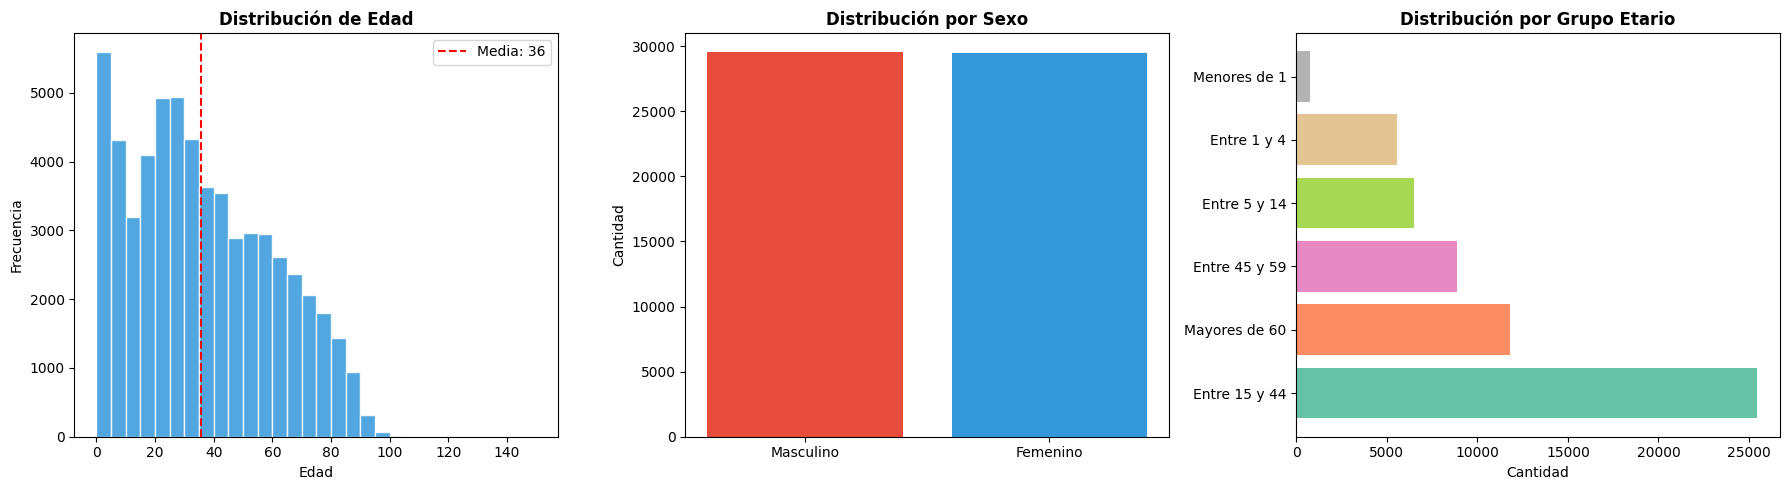

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución de edad
axes[0].hist(df_clean['Edad'].dropna(), bins=30, color='#3498db',
             edgecolor='white', alpha=0.85)
axes[0].axvline(df_clean['Edad'].mean(), color='red', linestyle='--',
                label=f'Media: {df_clean["Edad"].mean():.0f}')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Edad', fontweight='bold')
axes[0].legend()

# Distribución por sexo
sexo_cts = df_clean['Sexo'].value_counts()
axes[1].bar(sexo_cts.index, sexo_cts.values,
            color=['#e74c3c', '#3498db'][:len(sexo_cts)])
axes[1].set_title('Distribución por Sexo', fontweight='bold')
axes[1].set_ylabel('Cantidad')

# Grupos etarios
grupo_cts = df_clean['GrupoEtario1'].value_counts()
axes[2].barh(grupo_cts.index, grupo_cts.values,
             color=plt.cm.Set2(np.linspace(0, 1, len(grupo_cts))))
axes[2].set_xlabel('Cantidad')
axes[2].set_title('Distribución por Grupo Etario', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Distribución de triaje por grupo etario

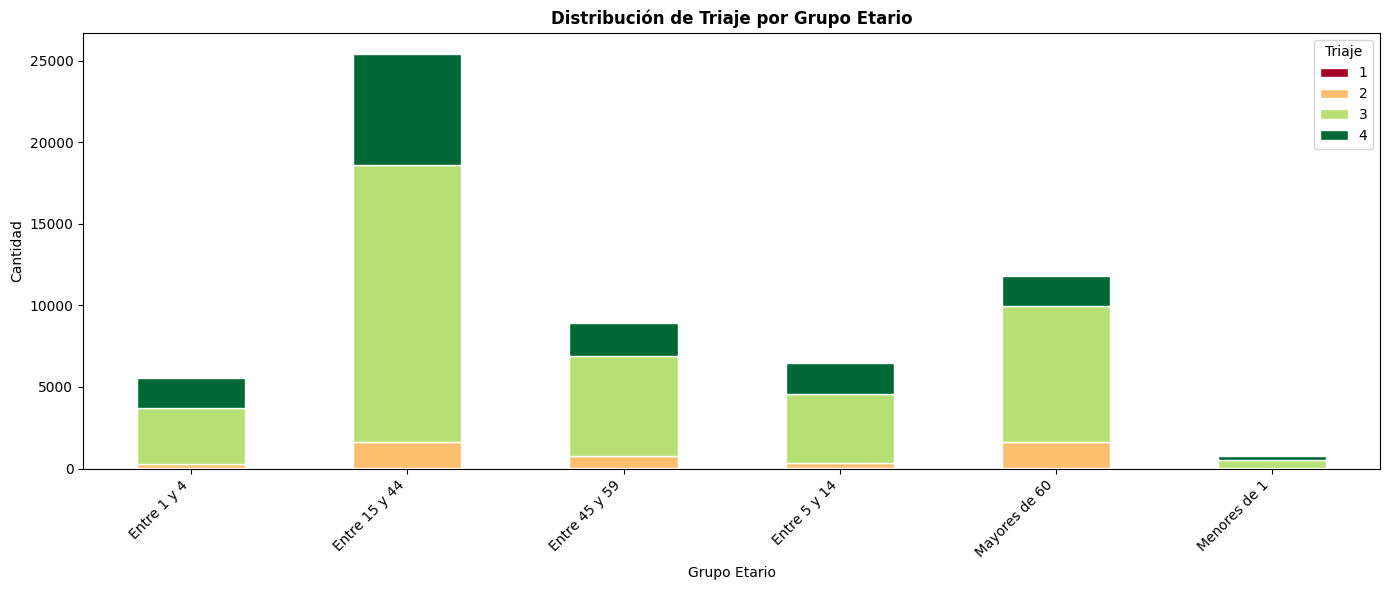

In [5]:
tabla = df_clean.groupby(['GrupoEtario1', 'Triage']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
tabla.plot(kind='bar', ax=ax, stacked=True,
           colormap='RdYlGn', edgecolor='white')
ax.set_xlabel('Grupo Etario')
ax.set_ylabel('Cantidad')
ax.set_title('Distribución de Triaje por Grupo Etario', fontweight='bold')
ax.legend(title='Triaje')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Unidad de atención

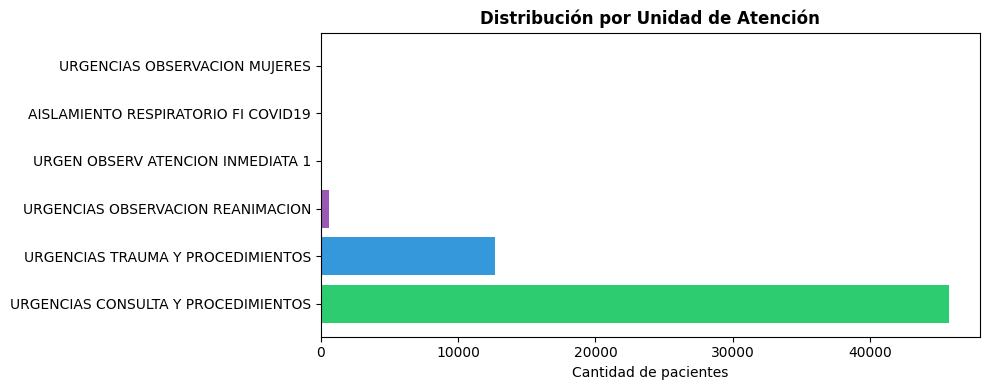

In [6]:
unidad_cts = df_clean['Unidad'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(unidad_cts.index, unidad_cts.values,
        color=['#2ecc71', '#3498db', '#9b59b6'][:len(unidad_cts)])
ax.set_xlabel('Cantidad de pacientes')
ax.set_title('Distribución por Unidad de Atención', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Triaje vs DxSindromatico (heatmap)

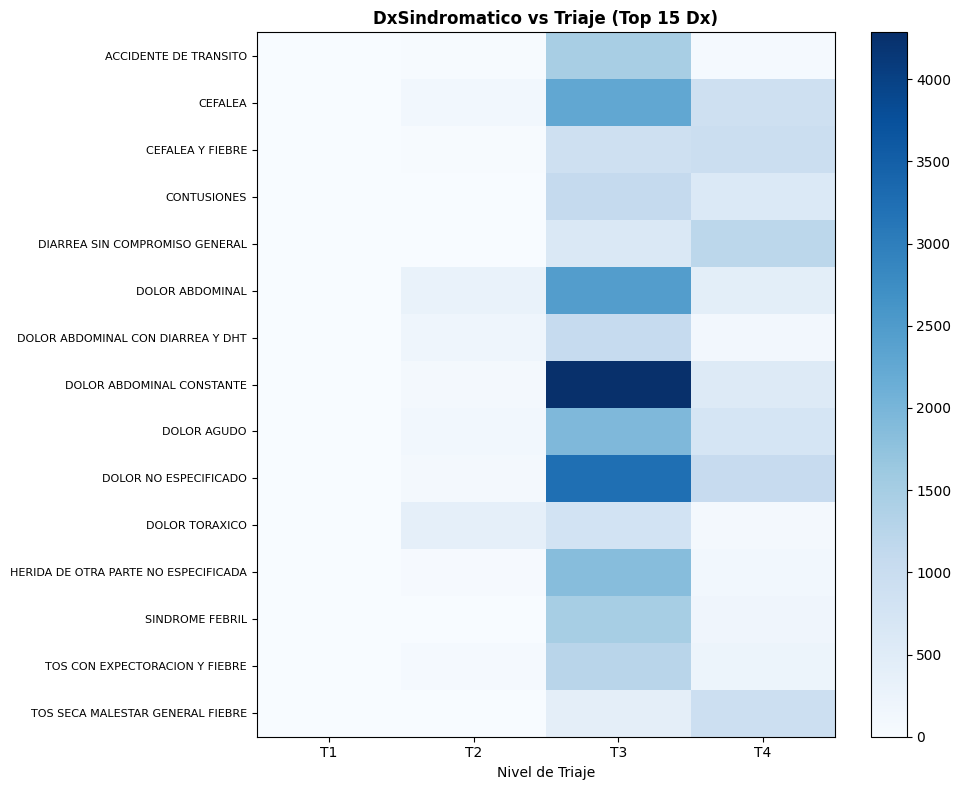

In [7]:
top15_dx = df_clean['DxSindromatico'].value_counts().head(15).index
cross = pd.crosstab(
    df_clean[df_clean['DxSindromatico'].isin(top15_dx)]['DxSindromatico'],
    df_clean[df_clean['DxSindromatico'].isin(top15_dx)]['Triage']
)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cross.values, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(cross.columns)))
ax.set_xticklabels([f'T{c}' for c in cross.columns])
ax.set_yticks(range(len(cross.index)))
ax.set_yticklabels(cross.index, fontsize=8)
ax.set_xlabel('Nivel de Triaje')
ax.set_title('DxSindromatico vs Triaje (Top 15 Dx)', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Análisis temporal

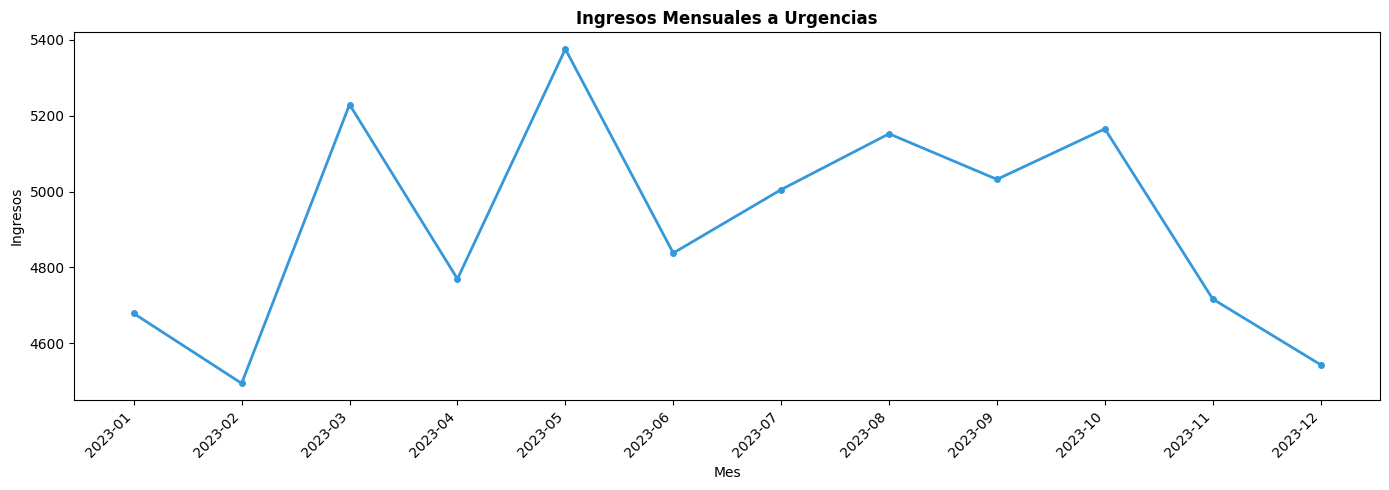

In [8]:
if 'FechaIngreso' in df_clean.columns:
    df_clean['FechaIngreso'] = pd.to_datetime(df_clean['FechaIngreso'], errors='coerce')
    mensual = df_clean.groupby(df_clean['FechaIngreso'].dt.to_period('M')).size()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(mensual.index.astype(str), mensual.values,
            color='#3498db', linewidth=2, marker='o', markersize=4)
    ax.set_xlabel('Mes')
    ax.set_ylabel('Ingresos')
    ax.set_title('Ingresos Mensuales a Urgencias', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Columna FechaIngreso no encontrada')

## 8. Resumen estadístico

In [9]:
print('=== RESUMEN DATASET MORBILIDAD ===')
print(f'Registros totales:     {len(df):,}')
print(f'Registros limpios:     {len(df_clean):,}')
print(f'DxSindromatico únicos: {df_clean["DxSindromatico"].nunique()}')
print(f'Edad media:            {df_clean["Edad"].mean():.1f} años')
print(f'Rango de edad:         {df_clean["Edad"].min()} – {df_clean["Edad"].max()}')
print()
print('Distribución de triaje:')
for k, v in df_clean['Triage'].value_counts().sort_index().items():
    pct = v / len(df_clean) * 100
    desc = TRIAJE_LABELS.get(k, '?')
    print(f'  T{k} ({desc}): {v:,} ({pct:.1f}%)')

=== RESUMEN DATASET MORBILIDAD ===
Registros totales:     59,025
Registros limpios:     59,001
DxSindromatico únicos: 297
Edad media:            35.8 años
Rango de edad:         0 – 150

Distribución de triaje:
  T1 (Resucitación): 132 (0.2%)
  T2 (Emergencia): 4,472 (7.6%)
  T3 (Urgencia): 39,706 (67.3%)
  T4 (Menos urgente): 14,691 (24.9%)
